Sample-specific persistent activity
Five subpopulations with three selective and one reset stimuli example. Analog to figure 6b in the paper.

BRUNEL, Nicolas et WANG, Xiao-Jing. Effects of neuromodulation in a cortical network model of object working memory dominated by recurrent inhibition. Journal of computational neuroscience, 2001, vol. 11, no 1, p. 63-85.

Copy from [Example: Brunel\_Wang\_2001 — Brian 2 2\.3 documentation](https://brian2.readthedocs.io/en/stable/examples/frompapers.Brunel_Wang_2001.html)

In [1]:
#from brian2 import *

import brian2
from brian2 import mV, nF, nS, ms, Hz, second
import numpy
import matplotlib.pyplot as plt

In [2]:
# populations
N = 1000
N_E = int(N * 0.8)  # pyramidal neurons
N_I = int(N * 0.2)  # interneurons

# voltage
#V_L = -70. * mV
#V_thr = -50. * mV
#V_reset = -55. * mV
#V_E = 0. * mV
#V_I = -70. * mV

# membrane capacitance
#C_m_E = 0.5 * nF
#C_m_I = 0.2 * nF

# membrane leak
#g_m_E = 25. * nS
#g_m_I = 20. * nS

# refractory period
#tau_rp_E = 2. * ms
#tau_rp_I = 1. * ms

# external stimuli
rate = 3 * Hz
C_ext = 800

# synapses
C_E = N_E
C_I = N_I

# AMPA (excitatory)
#g_AMPA_ext_E = 2.08 * nS
#g_AMPA_rec_E = 0.104 * nS * 800. / N_E
#g_AMPA_ext_I = 1.62 * nS
#g_AMPA_rec_I = 0.081 * nS * 800. / N_E
#tau_AMPA = 2. * ms

# NMDA (excitatory)
#g_NMDA_E = 0.327 * nS * 800. / N_E
#g_NMDA_I = 0.258 * nS * 800. / N_E
tau_NMDA_rise = 2. * ms
tau_NMDA_decay = 100. * ms
alpha = 0.5 / ms
#Mg2 = 1.

# GABAergic (inhibitory)
#g_GABA_E = 1.25 * nS * 200. / N_I
#g_GABA_I = 0.973 * nS * 200. / N_I
#tau_GABA = 10. * ms

# subpopulations
f = 0.1
p = 5
N_sub = int(N_E * f)
N_non = int(N_E * (1. - f * p))
w_plus = 2.1
w_minus = 1. - f * (w_plus - 1.) / (1. - f)


In [3]:
# modeling
import yaml
import load_models

eqs = '''
dv / dt = (- g_m * (v - V_L) - I_syn) / C_m : volt (unless refractory)

I_syn = I_AMPA_ext + I_AMPA_rec + I_NMDA_rec + I_GABA_rec : amp

I_AMPA_ext = g_AMPA_ext * (v - V_E) * s_AMPA_ext : amp
I_AMPA_rec = g_AMPA_rec * (v - V_E) * 1 * s_AMPA : amp
ds_AMPA_ext / dt = - s_AMPA_ext / tau_AMPA : 1
ds_AMPA / dt = - s_AMPA / tau_AMPA : 1

I_NMDA_rec = g_NMDA * (v - V_E) / (1 + Mg2 * exp(-0.062 * v / mV) / 3.57) * s_NMDA_tot : amp
s_NMDA_tot : 1

I_GABA_rec = g_GABA * (v - V_I) * s_GABA : amp
ds_GABA / dt = - s_GABA / tau_GABA : 1
'''

with open('neuron_parameters.yaml', 'r') as npf:
    neuron_parameters_dict = yaml.safe_load(npf)
n = neuron_parameters_dict['Pyramidal_Cells'].pop('N')
namespace = load_models.parse_name(spaceneuron_parameters_dict['Pyramidal_Cells'].pop('namespace'))
P_E = brian2.NeuronGroup(n, namespace=namespace, **spaceneuron_parameters_dict['Pyramidal_Cells'])

# modeling
namespace_E = {
    'V_L': -70*mV,
    'V_E': 0*mV,
    'V_I': -70*mV,
    'tau_AMPA': 2.*ms,
    'tau_GABA': 10.*ms,
    'Mg2': 1.,
    'C_m': 0.5*nF,
    'g_m': 25.*nS,
    'g_AMPA_ext': 2.08*nS,
    'g_AMPA_rec': 0.104*nS,
    'g_NMDA': 0.327*nS,
    'g_GABA': 1.25*nS,
}
namespace_I = {
    'V_L': -70*mV,
    'V_E': 0*mV,
    'V_I': -70*mV,
    'tau_AMPA': 2.*ms,
    'tau_GABA': 10.*ms,
    'Mg2': 1.,
    'C_m': 0.2*nF,
    'g_m': 20.*nS,
    'g_AMPA_ext': 1.62*nS,
    'g_AMPA_rec': 0.081*nS,
    'g_NMDA': 0.258*nS,
    'g_GABA': 0.973*nS,
}

eqs = '''
dv / dt = (- g_m * (v - V_L) - I_syn) / C_m : volt (unless refractory)

I_syn = I_AMPA_ext + I_AMPA_rec + I_NMDA_rec + I_GABA_rec : amp

I_AMPA_ext = g_AMPA_ext * (v - V_E) * s_AMPA_ext : amp
I_AMPA_rec = g_AMPA_rec * (v - V_E) * 1 * s_AMPA : amp
ds_AMPA_ext / dt = - s_AMPA_ext / tau_AMPA : 1
ds_AMPA / dt = - s_AMPA / tau_AMPA : 1

I_NMDA_rec = g_NMDA * (v - V_E) / (1 + Mg2 * exp(-0.062 * v / mV) / 3.57) * s_NMDA_tot : amp
s_NMDA_tot : 1

I_GABA_rec = g_GABA * (v - V_I) * s_GABA : amp
ds_GABA / dt = - s_GABA / tau_GABA : 1
'''

P_E = brian2.NeuronGroup(
    N_E, eqs, 
    threshold='v > -50. * mV', reset='v = -55. * mV', refractory='2.*ms',
    namespace=namespace_E, method='euler',
    )
P_E.v = -70*mV
P_I = brian2.NeuronGroup(
    N_I, eqs,
    threshold='v > -50. * mV', reset='v = -55. * mV', refractory='1.*ms',
    namespace=namespace_I, method='euler'
    )
P_I.v = -70*mV


In [4]:
eqs_glut = '''
s_NMDA_tot_post = w * s_NMDA : 1 (summed)
ds_NMDA / dt = - s_NMDA / tau_NMDA_decay + alpha * x * (1 - s_NMDA) : 1 (clock-driven)
dx / dt = - x / tau_NMDA_rise : 1 (clock-driven)
w : 1
'''

eqs_pre_glut = '''
s_AMPA += w
x += 1
'''

eqs_pre_gaba = '''
s_GABA += 1
'''

eqs_pre_ext = '''
s_AMPA_ext += 1
'''

# E to E
C_E_E = brian2.Synapses(P_E, P_E, model=eqs_glut, on_pre=eqs_pre_glut, method='euler')
C_E_E.connect('i != j')
C_E_E.w[:] = 1

for pi in range(N_non, N_non + p * N_sub, N_sub):

    # internal other subpopulation to current nonselective
    C_E_E.w[C_E_E.indices[:, pi:pi + N_sub]] = w_minus

    # internal current subpopulation to current subpopulation
    C_E_E.w[C_E_E.indices[pi:pi + N_sub, pi:pi + N_sub]] = w_plus

# E to I
C_E_I = brian2.Synapses(P_E, P_I, model=eqs_glut, on_pre=eqs_pre_glut, method='euler')
C_E_I.connect()
C_E_I.w[:] = 1

# I to I
C_I_I = brian2.Synapses(P_I, P_I, on_pre=eqs_pre_gaba, method='euler')
C_I_I.connect('i != j')

# I to E
C_I_E = brian2.Synapses(P_I, P_E, on_pre=eqs_pre_gaba, method='euler')
C_I_E.connect()

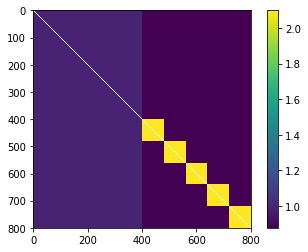

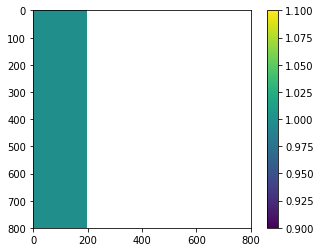

In [5]:
for C in [C_E_E, C_E_I]:
    W = numpy.full((P_E._N, P_E._N), numpy.nan)
    W[C.i[:], C.j[:]] = C.w[:]
    plt.imshow(W)
    plt.colorbar()
    plt.show()

In [6]:
# external noise
C_P_E = brian2.PoissonInput(P_E, 's_AMPA_ext', C_ext, rate, '1')
C_P_I = brian2.PoissonInput(P_I, 's_AMPA_ext', C_ext, rate, '1')

In [7]:
# at 1s, select population 1
C_selection = int(f * C_ext)
rate_selection = 25 * Hz
stimuli1 = brian2.TimedArray(numpy.r_[numpy.zeros(40), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input1 = brian2.PoissonInput(P_E[N_non:N_non + N_sub], 's_AMPA_ext', C_selection, rate_selection, 'stimuli1(t)')

# at 2s, select population 2
stimuli2 = brian2.TimedArray(numpy.r_[numpy.zeros(80), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input2 = brian2.PoissonInput(P_E[N_non + N_sub:N_non + 2 * N_sub], 's_AMPA_ext', C_selection, rate_selection, 'stimuli2(t)')

# at 4s, reset selection
stimuli_reset = brian2.TimedArray(numpy.r_[numpy.zeros(120), numpy.ones(2), numpy.zeros(100)], dt=25 * ms)
input_reset_I = brian2.PoissonInput(P_E, 's_AMPA_ext', C_ext, rate_selection, 'stimuli_reset(t)')
input_reset_E = brian2.PoissonInput(P_I, 's_AMPA_ext', C_ext, rate_selection, 'stimuli_reset(t)')


In [8]:
# monitors
N_activity_plot = 15
sp_E_sels = [brian2.SpikeMonitor(P_E[pi:pi + N_activity_plot]) for pi in range(N_non, N_non + p * N_sub, N_sub)]
sp_E = brian2.SpikeMonitor(P_E[:N_activity_plot])
sp_I = brian2.SpikeMonitor(P_I[:N_activity_plot])

r_E_sels = [brian2.PopulationRateMonitor(P_E[pi:pi + N_sub]) for pi in range(N_non, N_non + p * N_sub, N_sub)]
r_E = brian2.PopulationRateMonitor(P_E[:N_non])
r_I = brian2.PopulationRateMonitor(P_I)

In [9]:
# simulate, can be long >120s
net = brian2.Network(brian2.collect())
net.add(sp_E_sels)
net.add(r_E_sels)
net.run(4 * second, report='stdout')

Starting simulation at t=0. s for a duration of 4. s
0.341 s (8%) simulated in 10s, estimated 1m 47s remaining.
0.6901 s (17%) simulated in 20s, estimated 1m 36s remaining.
1.0346 s (25%) simulated in 30s, estimated 1m 26s remaining.
1.3727 s (34%) simulated in 40s, estimated 1m 17s remaining.
1.7126 s (42%) simulated in 50s, estimated 1m 7s remaining.
2.0236 s (50%) simulated in 1m 0s, estimated 59s remaining.
2.3133 s (57%) simulated in 1m 10s, estimated 51s remaining.
2.6036 s (65%) simulated in 1m 20s, estimated 43s remaining.
2.884 s (72%) simulated in 1m 30s, estimated 35s remaining.
3.1985 s (79%) simulated in 1m 40s, estimated 25s remaining.
3.5454 s (88%) simulated in 1m 50s, estimated 14s remaining.
3.8957 s (97%) simulated in 2m 0s, estimated 3s remaining.
4. s (100%) simulated in 2m 3s


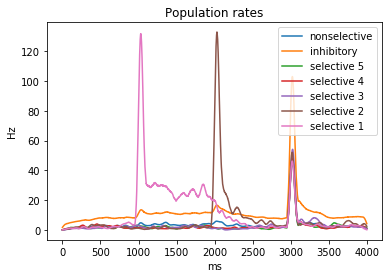

In [10]:
plt.title('Population rates')
plt.xlabel('ms')
plt.ylabel('Hz')

plt.plot(r_E.t / ms, r_E.smooth_rate(width=25 * ms) / Hz, label='nonselective')
plt.plot(r_I.t / ms, r_I.smooth_rate(width=25 * ms) / Hz, label='inhibitory')

for i, r_E_sel in enumerate(r_E_sels[::-1]):
    plt.plot(r_E_sel.t / ms, r_E_sel.smooth_rate(width=25 * ms) / Hz, label='selective {}'.format(p - i))

plt.legend()

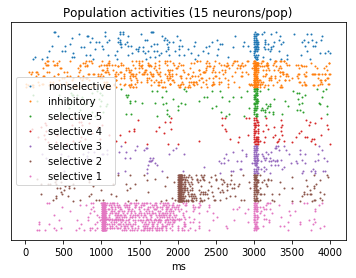

In [11]:
plt.title('Population activities ({} neurons/pop)'.format(N_activity_plot))
plt.xlabel('ms')
plt.yticks([])

plt.plot(sp_E.t / ms, sp_E.i + (p + 1) * N_activity_plot, '.', markersize=2, label='nonselective')
plt.plot(sp_I.t / ms, sp_I.i + p * N_activity_plot, '.', markersize=2, label='inhibitory')

for i, sp_E_sel in enumerate(sp_E_sels[::-1]):
    plt.plot(sp_E_sel.t / ms, sp_E_sel.i + (p - i - 1) * N_activity_plot, '.', markersize=2, label='selective {}'.format(p - i))

plt.legend()